In [124]:
print("reck98")
!(which python)
!(python --version)

reck98
/run/media/reck98/Others/Development/ML_NLP_DL/Ml-algorithms/.venv/bin/python
Python 3.12.12


In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings("ignore")

In [126]:
## We try to make a decision line as we did in the linear regression 

## Like , if we have data of weights and isObese or not, we make a line and see how it looks

In [127]:
weights = np.array([120, 130, 140, 150, 160, 170, 180, 190, 200, 210])

isObese = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

print(len(isObese) == len(weights))

True


Text(130, 0.6, 'Decision line')

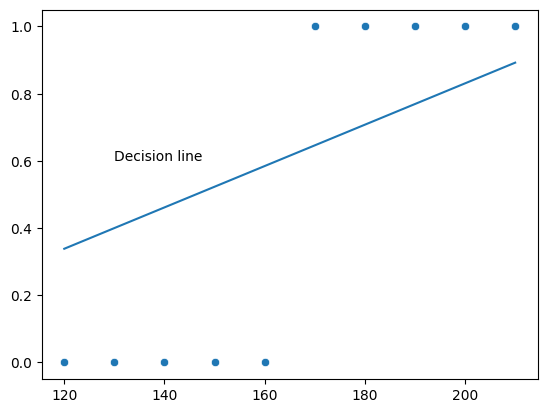

In [128]:
sns.scatterplot(x = weights, y = isObese)
# plt.axvline(x = 160)

## y = 0, x = 130, x = 0, y = -0.4

y = -0.4 +  weights * (0.8 /130)

plt.plot(weights, y)
plt.annotate("Decision line", (130, 0.6))

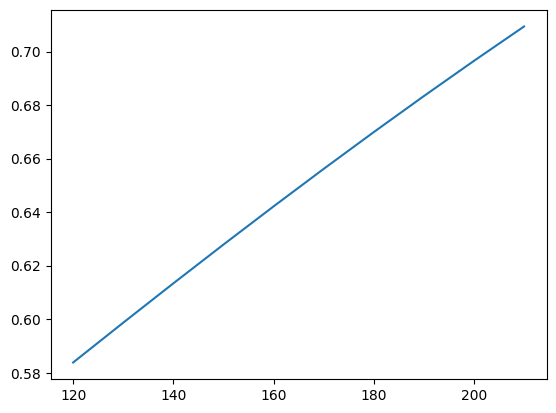

In [129]:
## But because of outliers , this line is heavly influenced by them

## So we use Sigmoid Function to make a S shaped line (Squash the line) as there is only two outcomes


def sigmoidFunc(y):
    val = 1 / (1 + np.exp(-y))
    return val


ySigmoid = sigmoidFunc(y)
plt.plot(weights, ySigmoid)

## Abhi esaa dikh rha, but more data points pr ache se dikhega

In [130]:
## For cost function --> We use log loss function 

## Our aim is to reduce the loss 

In [131]:
''' 
    Log Loss Function --> Binary Cross Entropy
    
    Same name --> Use to find the loss in logistic regression
'''

' \n    Log Loss Function --> Binary Cross Entropy\n\n    Same name --> Use to find the loss in logistic regression\n'

In [132]:
## Basic Project --> Titanic Dataset


In [133]:
originalDF = sns.load_dataset("titanic")
originalDF.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [134]:
df = originalDF.copy()

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [136]:
df.drop(["deck", "embark_town", "alive", "class", "who", "adult_male"], axis = 1, inplace = True)

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [138]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
alone         0
dtype: int64

In [139]:
df['age'].fillna(df['age'].mean(), inplace = True)

In [140]:
df.dropna(subset=["embarked"], inplace = True)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 63.4+ KB


In [142]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [143]:
df['pclass'].value_counts()

categoricalCols = ["pclass", "sex", "sibsp", "parch", "embarked", "alone"]

In [144]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categoricalCols:
    df[col] = encoder.fit_transform(df[col])

In [145]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,2,1,22.0,1,0,7.2500,2,0
1,1,0,0,38.0,1,0,71.2833,0,0
2,1,2,0,26.0,0,0,7.9250,2,1
3,1,0,0,35.0,1,0,53.1000,2,0
4,0,2,1,35.0,0,0,8.0500,2,1


In [146]:
numericCols = ["age", "fare"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numericCols] = scaler.fit_transform(df[numericCols])

In [147]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,2,1,-0.590495,1,0,-0.500240,2,0
1,1,0,0,0.643971,1,0,0.788947,0,0
2,1,2,0,-0.281878,0,0,-0.486650,2,1
3,1,0,0,0.412509,1,0,0.422861,2,0
4,0,2,1,0.412509,0,0,-0.484133,2,1


In [148]:
X = df.drop("survived", axis = 1)
y = df["survived"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [149]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [150]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [151]:
print(y_test)

281    0
435    1
39     1
418    0
585    1
      ..
433    0
807    0
25     1
85     1
10     1
Name: survived, Length: 178, dtype: int64


In [152]:
correct = 0

for i in range(len(y_pred)):
    if y_pred[i] == y_test.values[i]:
        correct += 1

print(correct)
print(correct / len(y_pred))

143
0.8033707865168539


In [153]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()

print(tn, fp, fn, tp)

acc = (tp + tn) / (tp + tn + fp + fn)

print(f"{round(acc * 100, 2)}%")
accuracy_score(y_test, y_pred)

90 19 16 53
80.34%


0.8033707865168539

In [154]:
prec = tp / (tp + fp)

print(f"{round(prec * 100, 2)}%")

precision_score(y_test, y_pred)

73.61%


0.7361111111111112

In [155]:
recall = tp / (tp + fn)

print(f"{round(recall * 100, 2)}%")
recall_score(y_test, y_pred)


76.81%


0.7681159420289855

In [157]:
f1Score = 2 * (prec * recall) / (prec + recall)

print(f"{round(f1Score * 100, 2)}%")
f1_score(y_test, y_pred)

75.18%


0.75177304964539

In [158]:
print(f" Accuracy: {round(accuracy_score(y_test, y_pred) * 100, 2)}%")
print(f" Precision: {round(precision_score(y_test, y_pred) * 100, 2)}%")
print(f" Recall: {round(recall_score(y_test, y_pred) * 100, 2)}%")
print(f" F1 Score: {round(f1_score(y_test, y_pred) * 100, 2)}%")

 Accuracy: 80.34%
 Precision: 73.61%
 Recall: 76.81%
 F1 Score: 75.18%
